# <span style='color:Red'>Misbinding models (Part 2)</span>

## <span style='color:Red'>Libraries, functions, paths</span>

In [1]:
import sys, os
from pathlib import Path

currentWD = os.path.dirname(Path.cwd())
if currentWD not in sys.path:
    sys.path.append(currentWD)
#print(sys.path)

import numpy, pandas, re, ast, seaborn, jlib, sklearn, pickle
from matplotlib import pyplot

saveFigs = True
imagePath = 'img/models/'
imageFormats = ['svg','pdf']
exportsPathBase = 'exports/'
exportsPath = 'exports/biasModels/'
exportsPathTemp = 'exports/biasModels/temp/full/'

significanceSize = 14

paletteBase = {'Chunkable':'#a1c9f4','Non-chunkable':'#ffb482'}

if not os.path.exists(imagePath):
    os.makedirs(imagePath)

if not os.path.exists(exportsPath):
    os.makedirs(exportsPath)

if not os.path.exists(exportsPathTemp):
    os.makedirs(exportsPathTemp)

mapValueHandler = jlib.data.mapValueHandler.MapValueHandler(exportsPathBase+"exp3Values.csv")

modelComparisonData = pandas.read_csv(exportsPath+'modelsTrainBIC_SPMBSM_df.csv')

allParticipantData = pandas.read_csv(exportsPathBase+'participantData_long_preEEG.csv')
allParticipantData.drop(['Mouse X path','Mouse Y path','Target'],axis=1,inplace=True)

## <span style='color:Red'>Fit all trials together</span>

In [2]:
if not os.path.exists(exportsPathTemp+'allFits.pkl'):
    allFits,allBIC = jlib.analysis.models.fitAllBiasModelsCV(allParticipantData,'all','BIC',nFolds=1,nJobs=5)
    with open(exportsPathTemp+'allFits.pkl','wb') as fp:
        pickle.dump(allFits,fp)
    with open(exportsPathTemp+'allBIC.pkl','wb') as fp:
        pickle.dump(allBIC,fp)
else:
    with open(exportsPathTemp+'allFits.pkl','rb') as fp:
        allFits = pickle.load(fp)
    with open(exportsPathTemp+'allBIC.pkl','rb') as fp:
        allBIC = pickle.load(fp)

In [3]:
finalBICTrain = {'MBSK_all':[],'MBDK_all':[],'NMB_all':[],'Bias_all':[]}

for participant in numpy.unique(allParticipantData['Subject']):
    a = numpy.array(allBIC['MBSK'][participant])
    b = numpy.array(allBIC['MBDK'][participant])
    c = numpy.array(allBIC['NMB'][participant])
    d = numpy.array(allBIC['Bias'][participant])

    finalBICTrain['MBSK_all'].append(numpy.sum(a,axis=0)[0])
    finalBICTrain['MBDK_all'].append(numpy.sum(b,axis=0)[0])
    finalBICTrain['NMB_all'].append(numpy.sum(c,axis=0)[0])
    finalBICTrain['Bias_all'].append(numpy.sum(d,axis=0)[0])

numpy.sum(finalBICTrain['MBSK_all']),numpy.sum(finalBICTrain['MBDK_all']),numpy.sum(finalBICTrain['NMB_all']),numpy.sum(finalBICTrain['Bias_all'])

(39086.37237094953, 38913.6137726876, 38936.13840918449, 37294.38142755618)

## <span style='color:Red'>Fit chunking vs non-chunking trials</span>

In [4]:
chunkingData = allParticipantData.copy()
chunkingData.drop(chunkingData[chunkingData['Trial type']=='Non-chunkable'].index,axis=0,inplace=True)
nonChunkingData = allParticipantData.copy()
nonChunkingData.drop(nonChunkingData[nonChunkingData['Trial type']=='Chunkable'].index,axis=0,inplace=True)

if not os.path.exists(exportsPathTemp+'allFitsChunking.pkl'):
    allFitsChunking,allBICChunking = jlib.analysis.models.fitAllBiasModelsCV(chunkingData,'all','BIC',nFolds=1,nJobs=5)
    with open(exportsPathTemp+'allFitsChunking.pkl','wb') as fp:
        pickle.dump(allFitsChunking,fp)
    with open(exportsPathTemp+'allBICChunking.pkl','wb') as fp:
        pickle.dump(allBICChunking,fp)

    allFitsNonChunking,allBICNonChunking = jlib.analysis.models.fitAllBiasModelsCV(nonChunkingData,'all','BIC',nFolds=1,nJobs=5)
    with open(exportsPathTemp+'allFitsNonChunking.pkl','wb') as fp:
        pickle.dump(allFitsNonChunking,fp)
    with open(exportsPathTemp+'allBICNonChunking.pkl','wb') as fp:
        pickle.dump(allBICNonChunking,fp)
else:
    with open(exportsPathTemp+'allFitsChunking.pkl','rb') as fp:
        allFitsChunking = pickle.load(fp)
    with open(exportsPathTemp+'allBICChunking.pkl','rb') as fp:
        allBICChunking = pickle.load(fp)
    with open(exportsPathTemp+'allFitsNonChunking.pkl','rb') as fp:
        allFitsNonChunking = pickle.load(fp)
    with open(exportsPathTemp+'allBICNonChunking.pkl','rb') as fp:
        allBICNonChunking = pickle.load(fp)

In [5]:
allFitsChunking

{'MBSK': {302: [{'kappaT': array(6.43629632),
    'kappaNT': 0,
    'targetP': 0.8447198223424719,
    'nonTargetP': 0.0010488985279212388,
    'guessingP': 0.15423127912960688}],
  303: [{'kappaT': array(18.57677447),
    'kappaNT': 0,
    'targetP': 0.516407111385034,
    'nonTargetP': 6.5975372285557585e-06,
    'guessingP': 0.48358629107773726}],
  305: [{'kappaT': array(18.15904414),
    'kappaNT': 0,
    'targetP': 0.662000302086803,
    'nonTargetP': 1.6388704628478453e-06,
    'guessingP': 0.33799805904273406}],
  306: [{'kappaT': array(5.33156761),
    'kappaNT': 0,
    'targetP': 0.49050656268938225,
    'nonTargetP': 4.7245566035217584e-05,
    'guessingP': 0.5094461917445825}],
  307: [{'kappaT': array(14.89768327),
    'kappaNT': 0,
    'targetP': 0.9467520003952068,
    'nonTargetP': 7.918909327769252e-07,
    'guessingP': 0.053247207713860524}],
  308: [{'kappaT': array(13.82796081),
    'kappaNT': 0,
    'targetP': 0.5079022988786005,
    'nonTargetP': 0.000188937041097

In [6]:
models = ['MBSK','MBDK','Bias','NMB']
finalMeanParams = {}
finalSTDParams = {}

for key in models:
    finalMeanParams[key] = []
    finalSTDParams[key] = []

for recoveredModel in allFitsChunking:
    keys = allFitsChunking[recoveredModel][302][0].keys()

    means = {k: numpy.mean([allFitsChunking[recoveredModel][d][0][k] for d in allFitsChunking[recoveredModel]]) for k in keys}
    stds = {k: numpy.std([allFitsChunking[recoveredModel][d][0][k] for d in allFitsChunking[recoveredModel]]) for k in keys}
    finalMeanParams[recoveredModel] = means
    finalSTDParams[recoveredModel] = stds

In [7]:
finalMeanParams

{'MBSK': {'kappaT': 12.916473196660807,
  'kappaNT': 0.0,
  'targetP': 0.7591130019047717,
  'nonTargetP': 0.008537467824563539,
  'guessingP': 0.23234953027066463},
 'MBDK': {'kappaT': 16.117418195506158,
  'kappaNT': 5.17017947376142,
  'targetP': 0.693888442195682,
  'nonTargetP': 0.16561921263720902,
  'guessingP': 0.1404923451671091},
 'Bias': {'kappa': 15.922030418519071,
  'bias': 0.40598097338733236,
  'guessingP': 0.23816181223706548},
 'NMB': {'kappaT': 12.875918437617777,
  'kappaNT': 0.0,
  'targetP': 0.7680191949794913,
  'nonTargetP': 0.0,
  'guessingP': 0.23198080502050877}}

In [8]:
finalSTDParams

{'MBSK': {'kappaT': 5.694028471789661,
  'kappaNT': 0.0,
  'targetP': 0.16258978030143553,
  'nonTargetP': 0.0253399403174364,
  'guessingP': 0.15522951681059594},
 'MBDK': {'kappaT': 5.825553406183994,
  'kappaNT': 12.934599742885364,
  'targetP': 0.20159813325627748,
  'nonTargetP': 0.16985751051772074,
  'guessingP': 0.14326009257976843},
 'Bias': {'kappa': 7.625933458268311,
  'bias': 0.2891548130374629,
  'guessingP': 0.15607460009483906},
 'NMB': {'kappaT': 5.7108627833446715,
  'kappaNT': 0.0,
  'targetP': 0.15492271870110774,
  'nonTargetP': 0.0,
  'guessingP': 0.15492271870110771}}

In [9]:
propsToAdd = ['MBSK_C_all','MBDK_C_all','NMB_C_all','Bias_C_all',
              'MBSK_NC_all','MBDK_NC_all','NMB_NC_all','Bias_NC_all']
for prop in propsToAdd:
    finalBICTrain[prop] = []

for participant in numpy.unique(allParticipantData['Subject']):
    a = numpy.array(allBICChunking['MBSK'][participant])
    b = numpy.array(allBICChunking['MBDK'][participant])
    c = numpy.array(allBICChunking['NMB'][participant])
    d = numpy.array(allBICChunking['Bias'][participant])

    finalBICTrain['MBSK_C_all'].append(numpy.sum(a,axis=0)[0])
    finalBICTrain['MBDK_C_all'].append(numpy.sum(b,axis=0)[0])
    finalBICTrain['NMB_C_all'].append(numpy.sum(c,axis=0)[0])
    finalBICTrain['Bias_C_all'].append(numpy.sum(d,axis=0)[0])

    a = numpy.array(allBICNonChunking['MBSK'][participant])
    b = numpy.array(allBICNonChunking['MBDK'][participant])
    c = numpy.array(allBICNonChunking['NMB'][participant])
    d = numpy.array(allBICNonChunking['Bias'][participant])

    finalBICTrain['MBSK_NC_all'].append(numpy.sum(a,axis=0)[0])
    finalBICTrain['MBDK_NC_all'].append(numpy.sum(b,axis=0)[0])
    finalBICTrain['NMB_NC_all'].append(numpy.sum(c,axis=0)[0])
    finalBICTrain['Bias_NC_all'].append(numpy.sum(d,axis=0)[0])

[numpy.sum(finalBICTrain['MBSK_C_all']),numpy.sum(finalBICTrain['MBDK_C_all']),
 numpy.sum(finalBICTrain['NMB_C_all']),numpy.sum(finalBICTrain['Bias_C_all'])]

[28587.55987699879, 28489.785327684178, 28439.1113503873, 26802.887277064143]

In [10]:
[numpy.sum(finalBICTrain['MBSK_NC_all']),numpy.sum(finalBICTrain['MBDK_NC_all']),
 numpy.sum(finalBICTrain['NMB_NC_all']),numpy.sum(finalBICTrain['Bias_NC_all'])]

[10223.113876287685, 10231.71670089427, 10117.77408975661, 10087.012807960426]

In [11]:
finalBICTrain['Subject'] = numpy.unique(allParticipantData['Subject'])
finalBICTrainDF = pandas.DataFrame.from_dict(finalBICTrain)

for col in finalBICTrainDF.columns:
    finalBICTrainDF[col] = finalBICTrainDF[col].apply(lambda x: x[0] if isinstance(x, (list, numpy.ndarray)) else x)

finalBICTrainDF.to_csv(exportsPath+"modelsTrainBIC.csv")

In [12]:
finalBICTrainDF

,MBSK_all,MBDK_all,NMB_all,Bias_all,MBSK_C_all,MBDK_C_all,NMB_C_all,Bias_C_all,MBSK_NC_all,MBDK_NC_all,NMB_NC_all,Bias_NC_all,Subject
0,1798.810564,1756.456484,1792.012542,1798.642055,1383.953361,1350.451935,1377.355620,1383.856337,422.416514,420.510971,418.277036,421.466913,302
1,2446.316271,2430.699236,2439.518330,2411.164190,1901.745288,1893.722987,1895.162836,1870.594367,552.415796,549.432376,547.219189,549.368244,303
2,1915.229666,1913.799054,1908.428115,1835.175756,1504.056306,1510.162151,1497.479181,1421.704157,414.234571,404.012959,409.024234,412.392746,305
3,2843.257978,2849.817595,2836.443761,2829.936328,2268.359479,2274.869998,2261.771465,2249.694684,587.500880,592.582229,583.001738,587.831038,306
4,826.008850,832.810067,819.207112,556.669926,509.300308,515.878093,502.722055,282.721200,306.705608,311.887773,301.512246,261.388719,307
5,2499.118453,2485.803545,2492.317138,2489.711847,1985.003669,1979.367711,1978.428761,1976.750554,527.666812,521.336070,522.475380,525.214113,308
6,1451.054180,1457.854305,1444.252616,1351.673709,1052.649026,1059.223992,1046.073084,935.729729,400.829491,405.270503,395.999490,401.024938,309
7,1430.096882,1433.622105,1423.294818,1219.456911,860.636810,865.499620,854.058377,647.044799,504.353396,508.399440,499.157834,495.124293,310
8,2042.594950,2045.076269,2036.023208,2041.791481,1605.614535,1611.014564,1599.270809,1604.732483,448.778393,446.799289,443.826165,448.970070,313
9,1153.132939,1139.280037,1146.330042,1000.770380,725.391072,703.135068,718.811447,581.003038,401.552048,406.357981,396.357847,392.955736,314


## <span style='color:Red'>Test alpha for all trials</span>

In [13]:
allBias = []
for participant in allFits['Bias']:
    allBias.append(allFits['Bias'][participant][0]['bias'])

allFitsTtestOS = jlib.analysis.ttest.ttestOSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                      variables=[allBias],
                                                      testValue=0,isStudent=True,isWilcoxon=False,hypothesis='dt',
                                                      effectSize=True,descriptives=True)

allFitsTtestOS['ttest'].columns = allFitsTtestOS['ttest'].columns.str.rstrip('[stud]')

# mapValueHandler.setKeyValue("ttestOSModelBiasAllTrials",
#                             jlib.data.constants.extractTtestResults(allFitsTtestOS['ttest'],0))
                            
allFitsTtestOS

R[write to console]: In addition: 
R[write to console]: Warning message:

R[write to console]: package 'jmv' was built under R version 4.4.3 



{'ttest':          var         name       sta    df         p     esType         e
 "set0"  set0  Student's t  6.137531  22.0  0.000004  Cohen's d  1.279764,
 'normality':         name         w         p
 "set0"  set0  0.933139  0.127847,
 'descriptives':         name  num      mean    median        sd        se
 "set0"  set0   23  0.375999  0.415111  0.293803  0.061262}

## <span style='color:Red'>Test all params for chunkable vs non-chunkable trials</span>

### <span style='color:Red'>Bias param test</span>

In [14]:
chunkingParams = {}
nonChunkingParams = {}

for participant in allFitsChunking['Bias']:
    for param in allFitsChunking['Bias'][participant][0].keys():
        if (param not in chunkingParams):
            chunkingParams[param] = []
            nonChunkingParams[param] = []
        chunkingParams[param].append(allFitsChunking['Bias'][participant][0][param])
        nonChunkingParams[param].append(allFitsNonChunking['Bias'][participant][0][param])

biasCvsNCFitsTtestOS = jlib.analysis.ttest.ttestOSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                            variables=[chunkingParams['bias'],nonChunkingParams['bias']],
                                                            testValue=0,isStudent=True,isWilcoxon=False,hypothesis='dt',
                                                            effectSize=True,descriptives=True)

biasCvsNCFitsTtestOS['ttest'].columns = biasCvsNCFitsTtestOS['ttest'].columns.str.rstrip('[stud]')

mapValueHandler.setKeyValue("biasParamCTrialMSE",
                            f'$M={numpy.mean(chunkingParams["bias"]):.2f}, SE={numpy.std(chunkingParams["bias"])/numpy.sqrt(len(chunkingParams["bias"])):.2f}$')
mapValueHandler.setKeyValue("biasParamNCTrialMSE",
                            f'$M={numpy.mean(nonChunkingParams["bias"]):.2f}, SE={numpy.std(nonChunkingParams["bias"])/numpy.sqrt(len(nonChunkingParams["bias"])):.2f}$')

mapValueHandler.setKeyValue("ttestOSModelBiasCTrial",
                            jlib.data.constants.extractTtestResults(biasCvsNCFitsTtestOS['ttest'],0,2))

mapValueHandler.setKeyValue("ttestOSModelBiasNCTrial",
                            jlib.data.constants.extractTtestResults(biasCvsNCFitsTtestOS['ttest'],1,2))

biasCvsNCFitsTtestOS

{'ttest':          var         name       sta    df         p     esType         e
 "set0"  set0  Student's t  6.585467  22.0  0.000001  Cohen's d  1.373165
 "set1"  set1  Student's t  2.597316  22.0  0.016443  Cohen's d  0.541578,
 'normality':         name         w         p
 "set0"  set0  0.944646  0.225857
 "set1"  set1  0.968215  0.646369,
 'descriptives':         name  num      mean    median        sd        se
 "set0"  set0   23  0.405981  0.416090  0.295653  0.061648
 "set1"  set1   23  0.194287  0.279038  0.358743  0.074803}

In [15]:
biasCvsNCFitsTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                            column1=chunkingParams['bias'],
                                                            column2=nonChunkingParams['bias'],
                                                            isStudent=True,isWilcoxon=False,hypothesis='oneGreater',
                                                            effectSize=True,descriptives=True)

biasCvsNCFitsTtestPS['ttest'].columns = biasCvsNCFitsTtestPS['ttest'].columns.str.rstrip('[stud]')

mapValueHandler.setKeyValue("ttestPSModelBiasCvsNCTrial",
                            jlib.data.constants.extractTtestResults(biasCvsNCFitsTtestPS['ttest'],0))

biasCvsNCFitsTtestPS

{'ttest':                            var1  var2           te       sta    df         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Student's t  3.744826  22.0  0.000561   
 
                               esType        e  
 {"i1":"set1","i2":"set2"}  Cohen's d  0.78085  ,
 'normality':                            var1 sep  var2         w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.969773  0.683573,
 'descriptives':          name  num         m       med        sd        se
 "set11"  set1   23  0.405981  0.416090  0.295653  0.061648
 "set21"  set2   23  0.194287  0.279038  0.358743  0.074803}

### <span style='color:Red'>Guessing param test</span>

In [16]:
guessingCvsNCFitsTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                                column1=nonChunkingParams['guessingP'],
                                                                column2=chunkingParams['guessingP'],
                                                                isStudent=True,isWilcoxon=False,hypothesis='oneGreater',
                                                                effectSize=True,descriptives=True)

guessingCvsNCFitsTtestPS['ttest'].columns = guessingCvsNCFitsTtestPS['ttest'].columns.str.rstrip('[stud]')

mapValueHandler.setKeyValue("ttestPSModelGuessingCvsNCTrial",
                            jlib.data.constants.extractTtestResults(guessingCvsNCFitsTtestPS['ttest'],0))

guessingCvsNCFitsTtestPS

{'ttest':                            var1  var2           te      sta    df         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Student's t  6.11577  22.0  0.000002   
 
                               esType         e  
 {"i1":"set1","i2":"set2"}  Cohen's d  1.275226  ,
 'normality':                            var1 sep  var2         w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.974485  0.794542,
 'descriptives':          name  num         m       med        sd        se
 "set11"  set1   23  0.388478  0.373675  0.151169  0.031521
 "set21"  set2   23  0.238162  0.202502  0.159582  0.033275}

### <span style='color:Red'>Kappa param test</span>

In [17]:
kappaCvsNCFitsTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                                column1=chunkingParams['kappa'],
                                                                column2=nonChunkingParams['kappa'],
                                                                isStudent=True,isWilcoxon=False,hypothesis='oneGreater',
                                                                effectSize=True,descriptives=True)

kappaCvsNCFitsTtestPS['ttest'].columns = kappaCvsNCFitsTtestPS['ttest'].columns.str.rstrip('[stud]')

mapValueHandler.setKeyValue("ttestPSModelKappaCvsNCTrial",
                            jlib.data.constants.extractTtestResults(kappaCvsNCFitsTtestPS['ttest'],0))

kappaCvsNCFitsTtestPS

{'ttest':                            var1  var2           te       sta    df         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Student's t  0.303964  22.0  0.382006   
 
                               esType         e  
 {"i1":"set1","i2":"set2"}  Cohen's d  0.063381  ,
 'normality':                            var1 sep  var2         w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.970826  0.708782,
 'descriptives':          name  num          m        med        sd        se
 "set11"  set1   23  15.922030  16.889951  7.797324  1.625854
 "set21"  set2   23  15.415534  13.300964  9.199400  1.918207}

### <span style='color:Red'>Quick correlation between diff in guessing and diff in bias</span>

In [18]:
import scipy.stats

x = numpy.array(chunkingParams['bias'])-numpy.array(nonChunkingParams['bias'])
y = numpy.array(chunkingParams['guessingP'])-numpy.array(nonChunkingParams['guessingP'])
scipy.stats.pearsonr(x,y),scipy.stats.spearmanr(x,y)

(PearsonRResult(statistic=-0.09556390267185239, pvalue=0.6644734791008986),
 SignificanceResult(statistic=-0.2075098814229249, pvalue=0.34207075853531865))

In [19]:
mapValueHandler.saveData()

All data saved correctly to exports/exp3Values.csv


## <span style='color:Red'>Figures for publication</span>

### <span style='color:Red'>Everything models</span>

C:\Users\juanm\AppData\Local\Temp\ipykernel_118868\4210832269.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  seaborn.boxplot(ax=ax['A'],data=chunkableTrialsDF,x='Model',y='LL',
C:\Users\juanm\AppData\Local\Temp\ipykernel_118868\4210832269.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax['A'].set_xticklabels(['LTM-same\nprecision','LTM-diff\nprecision','Biased','Null'],rotation=45)
C:\Users\juanm\AppData\Local\Temp\ipykernel_118868\4210832269.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  seaborn.boxplot(ax=ax['B'],data=nonChunkableTrialsDF,x='Model',y='LL',
C:\Users\juanm\AppData\Local\Temp\ipykernel_118868\4210

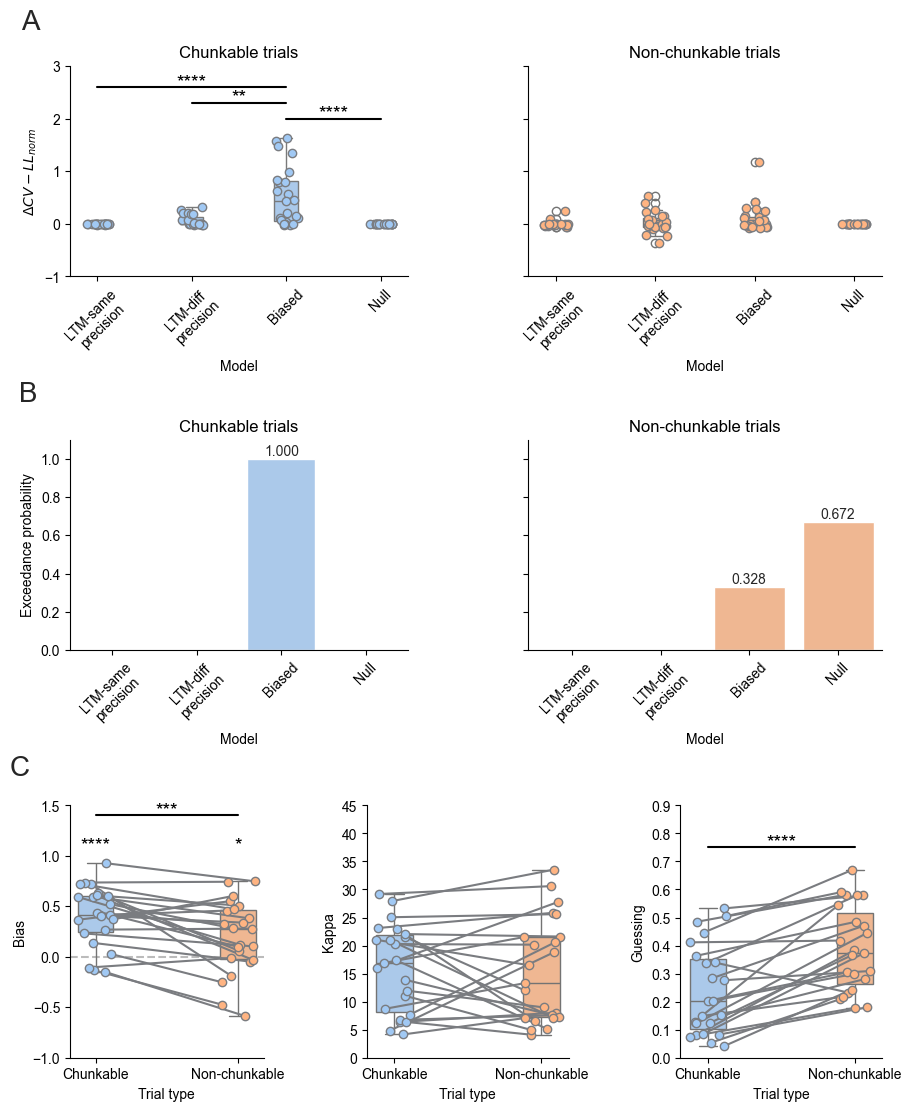

In [20]:
# Create the figure
fig,ax = pyplot.subplot_mosaic([['A','A','A','B','B','B'],['C','C','C','D','D','D'],['E','E','F','F','G','G']],
                               gridspec_kw={'height_ratios':[1,1,1.2],'wspace':0},
                               figsize=(9,11),constrained_layout=True)
seaborn.set_style('ticks')

# Ax[0,0]: Model comparison (CV-LL) for chunking trials
modelCVLLDF = pandas.read_csv(exportsPath+'modelsTestLL.csv',index_col=0)
chunkableTrialsDF = modelCVLLDF.filter(regex='Subject|_C_all').copy()
filterC = chunkableTrialsDF.columns.str.contains(r"_C_all")
chunkableTrialsDF.loc[:,filterC] = chunkableTrialsDF.loc[:,filterC].sub(chunkableTrialsDF['NMB_C_all'],axis=0)
chunkableTrialsDF = chunkableTrialsDF.melt(id_vars='Subject',var_name='Model',value_name='LL')
chunkableTrialsDF['Model'] = chunkableTrialsDF['Model'].str.replace('_C_all','',regex=True)
seaborn.boxplot(ax=ax['A'],data=chunkableTrialsDF,x='Model',y='LL',
                width=0.25,palette={'MBSK':'#a1c9f4','MBDK':'#a1c9f4','NMB':'#a1c9f4','Bias':'#a1c9f4'})
varCounter = 0
for condition in chunkableTrialsDF['Model'].unique():
    dataPoints = chunkableTrialsDF[chunkableTrialsDF['Model']==condition]
    jitter = (numpy.random.uniform(low=-0.5*0.25,high=0.5*0.25,size=(dataPoints.shape[0],)))
    ax['A'].plot(varCounter+jitter,dataPoints['LL'],marker='o',
                 markerfacecolor='#a1c9f4',markeredgecolor='#7a7c80',linestyle='None',zorder=1000)
    varCounter += 1
ax['A'].set_ylim(-1,3)
ax['A'].set_title("Chunkable trials")
ax['A'].set_ylabel(r"$\Delta CV-LL_{norm}$")
ax['A'].set_xticklabels(['LTM-same\nprecision','LTM-diff\nprecision','Biased','Null'],rotation=45)
pValue1 = float(re.search(r'(p=.*,)|(p<.*,)',mapValueHandler.data['ttestOSCTrialDiffBias-NMB']).group()[2:-1])
jlib.display.utils.displayPairwiseSignificance(ax['A'],[2,3],2*numpy.array([1,1]),size=significanceSize,
                                               p=pValue1)
pValue2 = float(re.search(r'(p=.*,)|(p<.*,)',mapValueHandler.data['ttestOSCTrialDiffBias-MBDK']).group()[2:-1])
jlib.display.utils.displayPairwiseSignificance(ax['A'],[1,2],2.3*numpy.array([1,1]),size=significanceSize,
                                               p=pValue2)
pValue3 = float(re.search(r'(p=.*,)|(p<.*,)',mapValueHandler.data['ttestOSCTrialDiffBias-MBSK']).group()[2:-1])
jlib.display.utils.displayPairwiseSignificance(ax['A'],[0,2],2.6*numpy.array([1,1]),size=significanceSize,
                                               p=pValue3)
ax['A'].text(-0.8,3.7,'A',fontsize=20)

# Ax[0,1]: Model comparison (CV-LL) for non-chunking trials
nonChunkableTrialsDF = modelCVLLDF.filter(regex='Subject|_NC_all').copy()
filterNC = nonChunkableTrialsDF.columns.str.contains(r"_NC_all")
nonChunkableTrialsDF.loc[:,filterNC] = nonChunkableTrialsDF.loc[:,filterNC].sub(nonChunkableTrialsDF['NMB_NC_all'],axis=0)
nonChunkableTrialsDF = nonChunkableTrialsDF.melt(id_vars='Subject',var_name='Model',value_name='LL')
nonChunkableTrialsDF['Model'] = nonChunkableTrialsDF['Model'].str.replace('_NC_all','',regex=True)
seaborn.boxplot(ax=ax['B'],data=nonChunkableTrialsDF,x='Model',y='LL',
                width=0.25,palette={'MBSK':'#ffb482','MBDK':'#ffb482','NMB':'#ffb482','Bias':'#ffb482'})
varCounter = 0
for condition in nonChunkableTrialsDF['Model'].unique():
    dataPoints = nonChunkableTrialsDF[nonChunkableTrialsDF['Model']==condition]
    jitter = (numpy.random.uniform(low=-0.5*0.25,high=0.5*0.25,size=(dataPoints.shape[0],)))
    ax['B'].plot(varCounter+jitter,dataPoints['LL'],marker='o',
                 markerfacecolor='#ffb482',markeredgecolor='#7a7c80',linestyle='None',zorder=1000)
    varCounter += 1
ax['B'].set_ylim(-1,3)
ax['B'].set_title("Non-chunkable trials")
ax['B'].set_ylabel("")
ax['B'].set_xticklabels(['LTM-same\nprecision','LTM-diff\nprecision','Biased','Null'],rotation=45)
ax['B'].set_yticklabels("")

# Ax[1,0]: Model comparison (SPM) for chunking trials
modelComparisonPlotData = {'Trial type':['Chunkable']*4+['Non-chunkable']*4,
                           'Model':['MBSK','MBDK','Bias','NMB']*2,
                           'Exceedance probability':[modelComparisonData.loc[1,'xp_MBSK'],modelComparisonData.loc[1,'xp_MBDK'],
                                                     modelComparisonData.loc[1,'xp_Bias'],modelComparisonData.loc[1,'xp_NMB'],
                                                     modelComparisonData.loc[2,'xp_MBSK'],modelComparisonData.loc[2,'xp_MBDK'],
                                                     modelComparisonData.loc[2,'xp_Bias'],modelComparisonData.loc[2,'xp_NMB']]}
modelComaprisonPlotDF = pandas.DataFrame.from_dict(modelComparisonPlotData)
seaborn.barplot(ax=ax['C'],
                data=modelComaprisonPlotDF.loc[modelComaprisonPlotDF['Trial type']=='Chunkable',:],
                x='Model',y='Exceedance probability',color=paletteBase['Chunkable'])
ax['C'].set_ylim(0,1.1)
ax['C'].text(-1.1,1.3,'B',fontsize=20)
ax['C'].set_title("Chunkable trials")
ax['C'].text(1.8,1.02,f"{modelComparisonData.loc[1,'xp_Bias']:.3f}")
ax['C'].set_xticklabels(['LTM-same\nprecision','LTM-diff\nprecision','Biased','Null'],rotation=45)

# Ax[1,1]: Model comparison (SPM) for non-chunking trials
seaborn.barplot(ax=ax['D'],
                data=modelComaprisonPlotDF.loc[modelComaprisonPlotDF['Trial type']=='Non-chunkable',:],
                x='Model',y='Exceedance probability',color=paletteBase['Non-chunkable'])
ax['D'].set_ylim(0,1.1)
ax['D'].set_title("Non-chunkable trials")
ax['D'].set_ylabel("")
ax['D'].set_yticklabels("")
ax['D'].text(1.8,0.35,f"{modelComparisonData.loc[2,'xp_Bias']:.3f}")
ax['D'].text(2.8,0.69,f"{modelComparisonData.loc[2,'xp_NMB']:.3f}")
ax['D'].set_xticklabels(['LTM-same\nprecision','LTM-diff\nprecision','Biased','Null'],rotation=45)

# Ax[2,0]: bias parameter
ax['E'].plot([-0.18,1.18],[0,0],'--',color='#bbbbbb')
plottingDictionary = {'Subject':numpy.concatenate((numpy.unique(allParticipantData['Subject']),numpy.unique(allParticipantData['Subject']))),
                      'Trial type':['Chunkable']*len(chunkingParams['bias'])+['Non-chunkable']*len(chunkingParams['bias']),
                      'Bias':chunkingParams['bias']+nonChunkingParams['bias'],
                      'Guessing':chunkingParams['guessingP']+nonChunkingParams['guessingP'],
                      'Kappa':chunkingParams['kappa']+nonChunkingParams['kappa']}
plottingDF = pandas.DataFrame.from_dict(plottingDictionary)
jlib.display.pairedObs.boxPlotPaired(ax=ax['E'],
                                     data=plottingDF,
                                     x='Trial type',y='Bias',
                                     width=0.25,palette=paletteBase)
ax['E'].set_ylim(-1,1.5)
ax['E'].set_xlim(-0.18,1.18)
jlib.display.utils.displayPairwiseSignificance(ax['E'],[0,1],1.4*numpy.array([1,1]),size=significanceSize,
                                               p=biasCvsNCFitsTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax['E'],0,1.05,size=significanceSize,
                                                p=2*biasCvsNCFitsTtestOS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax['E'],1,1.05,size=significanceSize,
                                                p=2*biasCvsNCFitsTtestOS['ttest']['p'].to_numpy()[1])
ax['E'].text(-0.6,1.8,'C',fontsize=20)

# Ax[2,1]: kappa parameter
jlib.display.pairedObs.boxPlotPaired(ax=ax['F'],
                                     data=plottingDF,
                                     x='Trial type',y='Kappa',
                                     width=0.25,palette=paletteBase)
ax['F'].set_ylim(0,45)

# Ax[2,2]: guessing parameter
jlib.display.pairedObs.boxPlotPaired(ax=ax['G'],
                                     data=plottingDF,
                                     x='Trial type',y='Guessing',
                                     width=0.25,palette=paletteBase)
ax['G'].set_ylim(0,0.9)
jlib.display.utils.displayPairwiseSignificance(ax['G'],[0,1],0.75*numpy.array([1,1]),size=significanceSize,
                                               p=guessingCvsNCFitsTtestPS['ttest']['p'].to_numpy()[0])

seaborn.despine()

if (saveFigs):
    for format in imageFormats:
        fig.savefig(imagePath+'biasModelsAndParams.'+format,format=format,dpi=1200)